# Framing Analysis: Google AI Overviews Across Locations

Compares how **Google AI Overviews** frame health information across four countries on dimensions of:
- **Specificity** (low / medium / high)
- **Medical referral & safety warnings**
- **TCM (Traditional Chinese Medicine) stance**

Data: `data/all_google_zero_shot.csv` · Platform: Google · Coding: zero-shot LLM

---

## 1  Setup & Imports

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations

os.makedirs("figures", exist_ok=True)

# ── Aesthetics ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "#f5f7fb",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.color": "#bdc8d8",
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

LOC_ORDER  = ["United States", "United Kingdom", "Australia", "India"]
LOC_COLORS = {
    "United States":  "#0d47a1",
    "United Kingdom": "#1976d2",
    "Australia":      "#42a5f5",
    "India":          "#90caf9",
}

SECTION_ORDER  = ["common_conditions", "legally_variable", "controversial", "tcm"]
SECTION_LABELS = {
    "common_conditions": "Common Conditions",
    "legally_variable":  "Legally Variable",
    "controversial":     "Controversial",
    "tcm":               "TCM",
}

FRAMING_COLS = [
    "specificity_low", "specificity_medium", "specificity_high",
    "tcm_pro", "tcm_skeptical", "tcm_not_applicable",
    "referral_to_medical_profession", "emergency_referral",
    "safety_warning_present", "safety_warning_absent",
]

DIM_LABELS = {
    "specificity_low":                "Specificity — Low",
    "specificity_medium":             "Specificity — Medium",
    "specificity_high":               "Specificity — High",
    "tcm_pro":                        "TCM — Pro",
    "tcm_skeptical":                  "TCM — Skeptical",
    "tcm_not_applicable":             "TCM — N/A",
    "referral_to_medical_profession": "Medical Referral",
    "emergency_referral":             "Emergency Referral",
    "safety_warning_present":         "Safety Warning",
    "safety_warning_absent":          "Safety Warning Absent",
}

## 2  Load & Validate Data

In [17]:
DATA_PATH = "data/all_google_zero_shot.csv"

df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["topic", "section"]).copy()

df["location"] = pd.Categorical(df["location"], categories=LOC_ORDER, ordered=True)
df["section"]  = pd.Categorical(df["section"],  categories=SECTION_ORDER, ordered=True)

print(f"Rows: {len(df)}  |  Columns: {df.shape[1]}")
print(f"Locations : {df['location'].cat.categories.tolist()}")
print(f"Sections  : {df['section'].cat.categories.tolist()}")
print(f"Topics    : {sorted(df['topic'].unique())}")
print()
print("Queries per location:")
print(df.groupby("location", observed=True)["query"].count().rename("n_queries").to_frame())
print()
print("Null counts in framing columns:")
print(df[FRAMING_COLS].isnull().sum()[lambda s: s > 0])

Rows: 316  |  Columns: 16
Locations : ['United States', 'United Kingdom', 'Australia', 'India']
Sections  : ['common_conditions', 'legally_variable', 'controversial', 'tcm']
Topics    : ['abortion', 'acupuncture', 'cancer', 'cupping', 'depression', 'diabetes', 'gender_affirming', 'hantavirus', 'herbal', 'hiv', 'hypertension', 'long_covid']

Queries per location:
                n_queries
location                 
United States          75
United Kingdom         81
Australia              81
India                  79

Null counts in framing columns:
Series([], dtype: int64)


## 3  Query Coverage by Location × Topic

Confirms balanced coverage across conditions and surfaces any gaps.

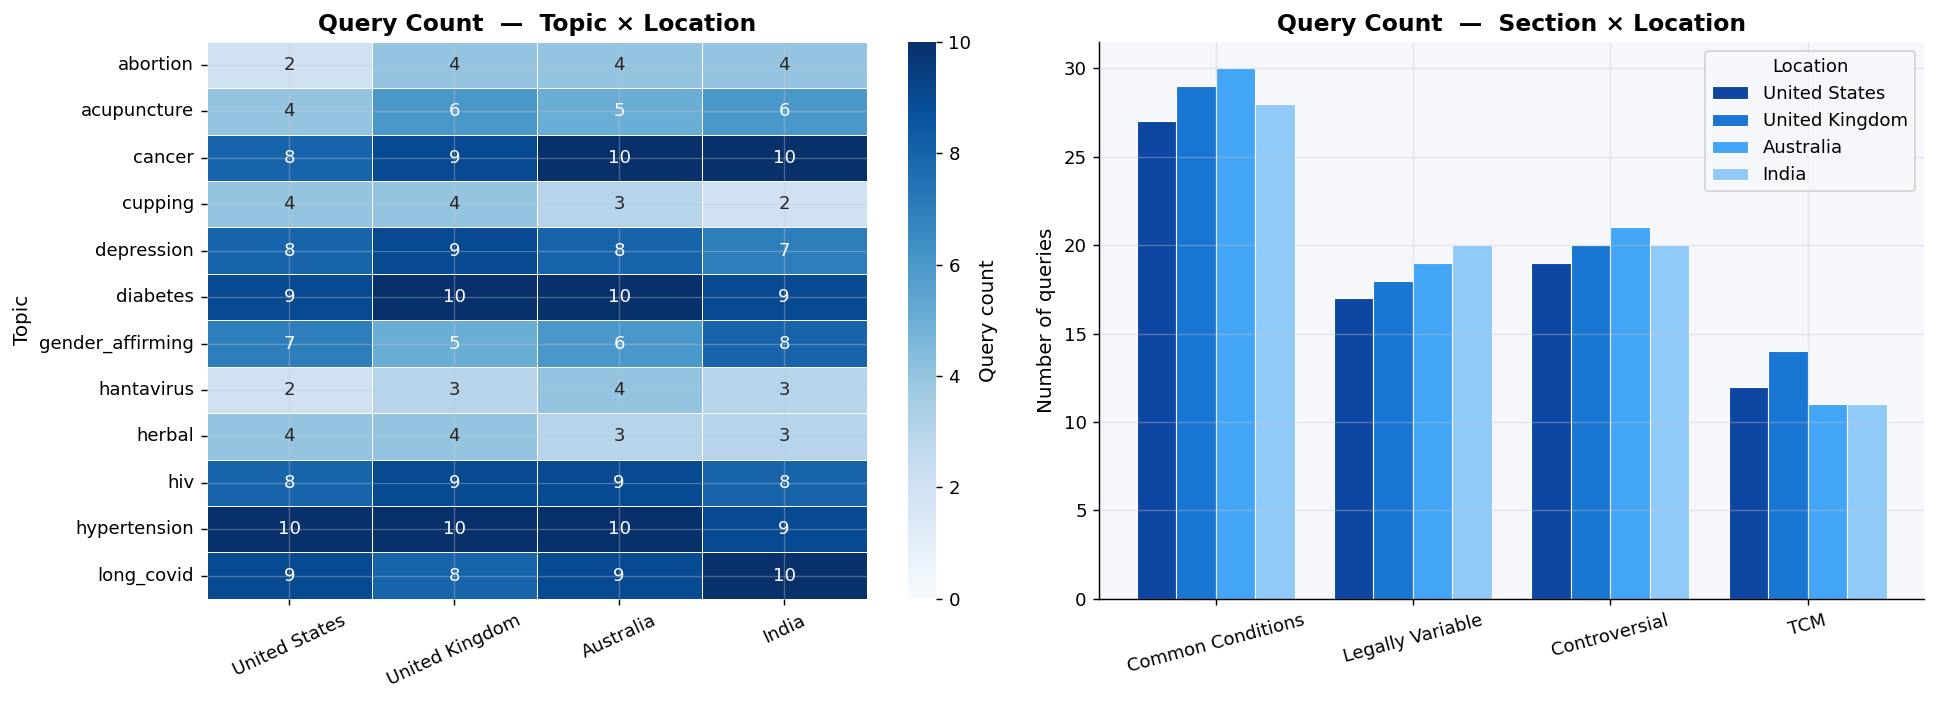

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── Left: query count heatmap (topic × location) ───────────────────────────
pivot_count = (
    df.groupby(["topic", "location"], observed=True)["query"]
    .count()
    .unstack("location")
    [LOC_ORDER]
    .fillna(0).astype(int)
)
sns.heatmap(
    pivot_count, ax=axes[0],
    annot=True, fmt="d", linewidths=0.5,
    cmap="Blues", vmin=0,
    cbar_kws={"label": "Query count"},
)
axes[0].set_title("Query Count  —  Topic × Location")
axes[0].set_xlabel("")
axes[0].set_ylabel("Topic")
axes[0].tick_params(axis="x", rotation=25)

# ── Right: query count by section × location ───────────────────────────────
pivot_sec = (
    df.groupby(["section", "location"], observed=True)["query"]
    .count()
    .unstack("location")
    [LOC_ORDER]
    .fillna(0).astype(int)
    .rename(index=SECTION_LABELS)
)
x = np.arange(len(pivot_sec))
width = 0.2
for i, loc in enumerate(LOC_ORDER):
    axes[1].bar(x + (i - 1.5) * width, pivot_sec[loc],
                width=width, label=loc, color=LOC_COLORS[loc],
                edgecolor="white", linewidth=0.6)
axes[1].set_title("Query Count  —  Section × Location")
axes[1].set_xticks(x)
axes[1].set_xticklabels(pivot_sec.index, rotation=15)
axes[1].set_ylabel("Number of queries")
axes[1].legend(title="Location")

plt.tight_layout()
plt.savefig("figures/01_coverage_overview.png", bbox_inches="tight")
plt.show()

## 4  Overall Framing Profile  (Radar Chart)

Four dimensions that apply across **all** topics — gives a gestalt view of how each country's AI differs.

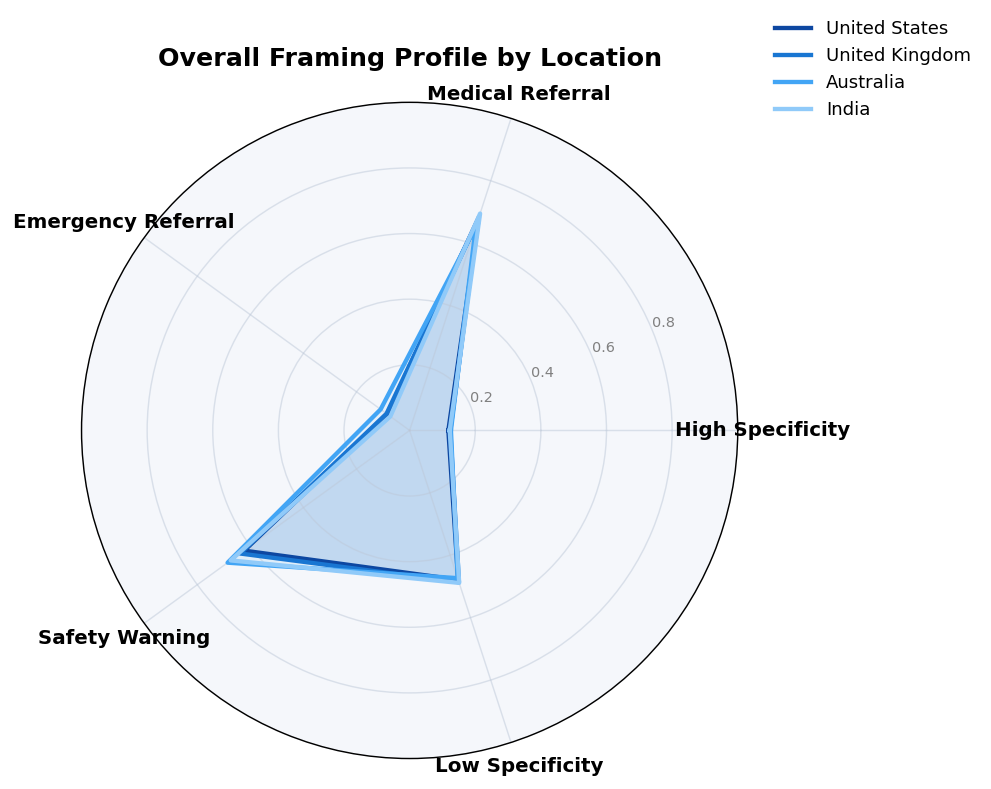

Mean values:
                High Specificity  Medical Referral  Emergency Referral  \
location                                                                 
United States              0.118             0.683               0.084   
United Kingdom             0.124             0.671               0.087   
Australia                  0.126             0.652               0.109   
India                      0.122             0.695               0.073   

                Safety Warning  Low Specificity  
location                                         
United States            0.623            0.479  
United Kingdom           0.638            0.486  
Australia                0.686            0.473  
India                    0.674            0.489  


In [19]:
RADAR_DIMS = [
    "specificity_high",
    "referral_to_medical_profession",
    "emergency_referral",
    "safety_warning_present",
    "specificity_low",
]
RADAR_LABELS = [
    "High Specificity",
    "Medical Referral",
    "Emergency Referral",
    "Safety Warning",
    "Low Specificity",
]

loc_means = (
    df.groupby("location", observed=True)[RADAR_DIMS]
    .mean()
    .loc[LOC_ORDER]
)

N = len(RADAR_DIMS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor("#f5f7fb")

for loc in LOC_ORDER:
    vals = loc_means.loc[loc, RADAR_DIMS].tolist() + [loc_means.loc[loc, RADAR_DIMS[0]]]
    ax.plot(angles, vals, linewidth=2.4, color=LOC_COLORS[loc], label=loc, zorder=3)
    ax.fill(angles, vals, alpha=0.08, color=LOC_COLORS[loc])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABELS, size=11, fontweight="bold")
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], size=8, color="grey")
ax.set_title("Overall Framing Profile by Location", size=14, pad=20, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.38, 1.15), frameon=False)
ax.grid(color="#bdc8d8", alpha=0.5)

plt.tight_layout()
plt.savefig("figures/02_radar_overall.png", bbox_inches="tight")
plt.show()

print("Mean values:")
print(loc_means[RADAR_DIMS].round(3).rename(columns=dict(zip(RADAR_DIMS, RADAR_LABELS))))

## 5  Specificity Analysis

**Specificity** measures how precise/detailed the AI response is.
Values are probabilities summing to ~1 across low / medium / high.

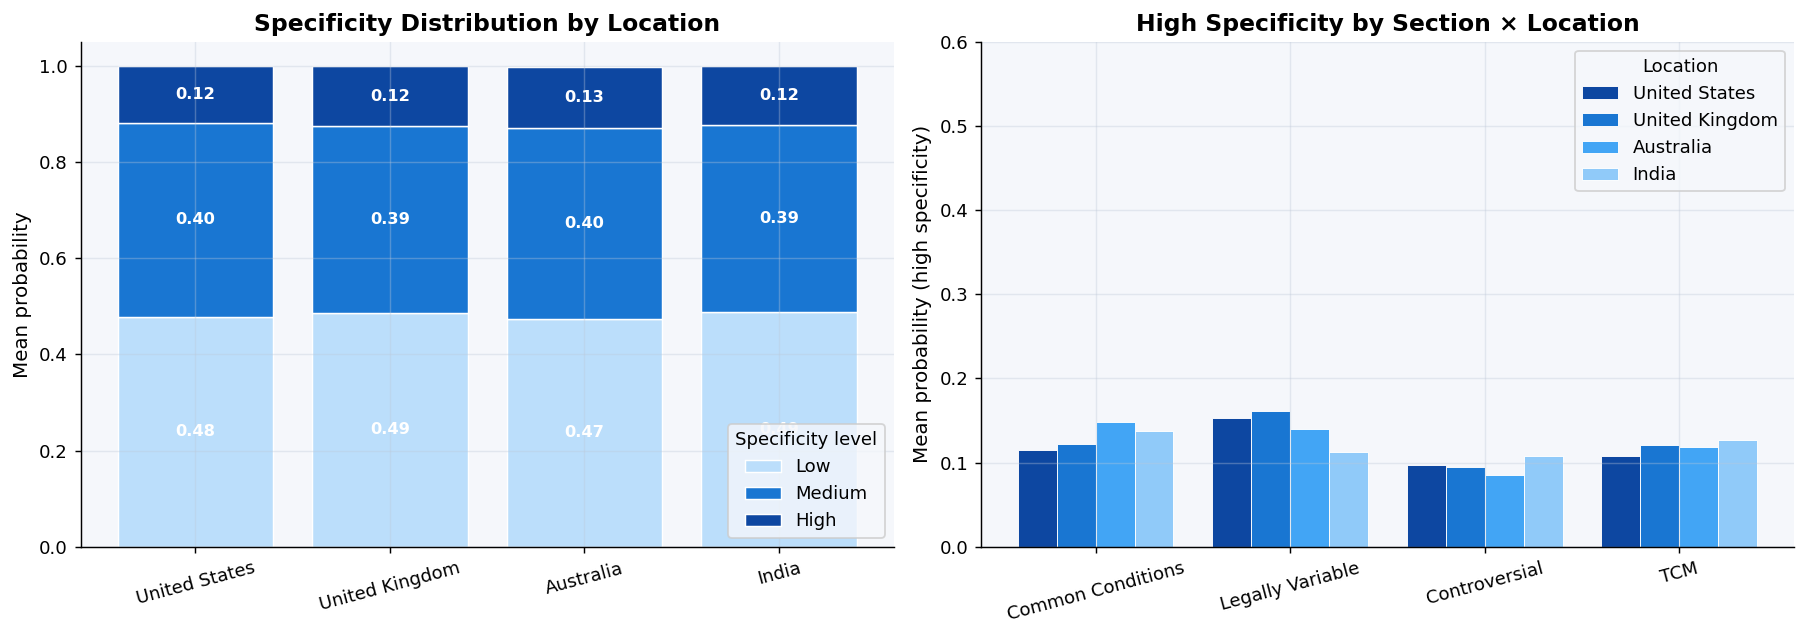


High specificity by location:
location
United States     0.118
United Kingdom    0.124
Australia         0.126
India             0.122
Name: specificity_high, dtype: float64


In [20]:
SPEC_COLS   = ["specificity_low", "specificity_medium", "specificity_high"]
SPEC_LABELS = ["Low", "Medium", "High"]
SPEC_COLORS = ["#bbdefb", "#1976d2", "#0d47a1"]

spec_loc = (
    df.groupby("location", observed=True)[SPEC_COLS]
    .mean()
    .loc[LOC_ORDER]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: stacked bar (full composition per location) ─────────────────────
bottom = np.zeros(len(LOC_ORDER))
for col, label, color in zip(SPEC_COLS, SPEC_LABELS, SPEC_COLORS):
    vals = spec_loc[col].values
    bars = axes[0].bar(LOC_ORDER, vals, bottom=bottom, label=label,
                       color=color, edgecolor="white", linewidth=0.8)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.06:
            axes[0].text(i, b + v / 2, f"{v:.2f}",
                         ha="center", va="center",
                         color="white", fontsize=9, fontweight="bold")
    bottom += vals

axes[0].set_title("Specificity Distribution by Location")
axes[0].set_ylabel("Mean probability")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(title="Specificity level", loc="lower right")

# ── Right: high specificity by section × location ─────────────────────────
spec_sec = (
    df.groupby(["section", "location"], observed=True)["specificity_high"]
    .mean()
    .unstack("location")
    [LOC_ORDER]
    .rename(index=SECTION_LABELS)
)
x = np.arange(len(spec_sec))
width = 0.2
for i, loc in enumerate(LOC_ORDER):
    axes[1].bar(x + (i - 1.5) * width, spec_sec[loc],
                width=width, label=loc, color=LOC_COLORS[loc],
                edgecolor="white", linewidth=0.5)

axes[1].set_title("High Specificity by Section × Location")
axes[1].set_ylabel("Mean probability (high specificity)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(spec_sec.index, rotation=15)
axes[1].set_ylim(0, 0.6)
axes[1].legend(title="Location")

plt.tight_layout()
plt.savefig("figures/03_specificity.png", bbox_inches="tight")
plt.show()

print("\nHigh specificity by location:")
print(spec_loc["specificity_high"].round(3).rename("specificity_high"))

## 6  Medical Referral & Safety Warnings

Does the AI recommend consulting a doctor, emergency services, or include safety caveats?

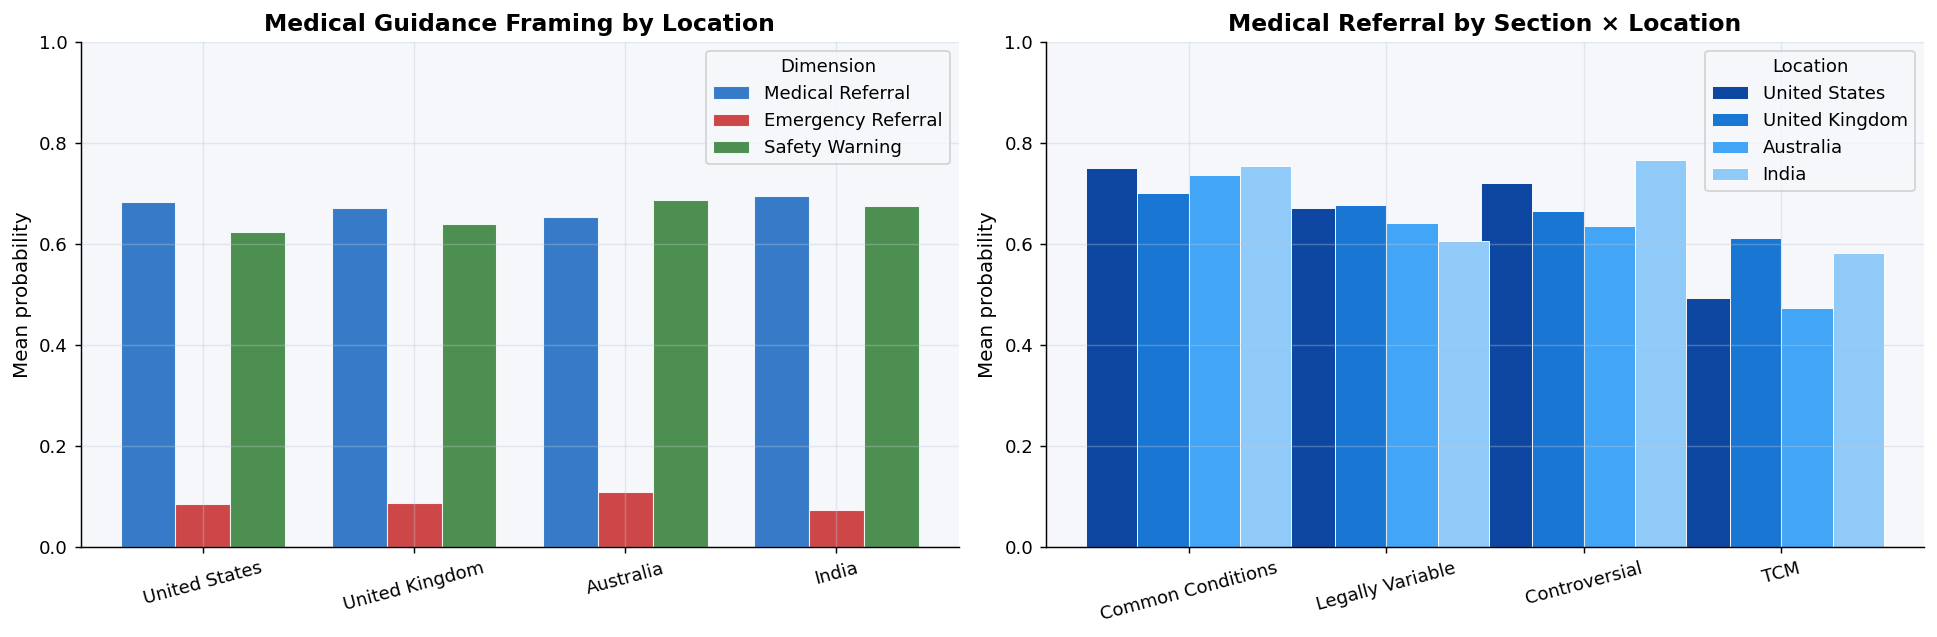

                Medical Referral  Emergency Referral  Safety Warning
location                                                            
United States              0.683               0.084           0.623
United Kingdom             0.671               0.087           0.638
Australia                  0.652               0.109           0.686
India                      0.695               0.073           0.674


In [21]:
GUID_COLS   = ["referral_to_medical_profession", "emergency_referral", "safety_warning_present"]
GUID_LABELS = ["Medical Referral", "Emergency Referral", "Safety Warning"]
GUID_COLORS = ["#1565c0", "#c62828", "#2e7d32"]

guide_loc = (
    df.groupby("location", observed=True)[GUID_COLS]
    .mean()
    .loc[LOC_ORDER]
    .rename(columns=dict(zip(GUID_COLS, GUID_LABELS)))
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: grouped bar by location ─────────────────────────────────────────
x = np.arange(len(LOC_ORDER))
width = 0.26
for i, (label, color) in enumerate(zip(GUID_LABELS, GUID_COLORS)):
    axes[0].bar(x + (i - 1) * width, guide_loc[label],
                width=width, label=label, color=color,
                alpha=0.85, edgecolor="white", linewidth=0.6)

axes[0].set_title("Medical Guidance Framing by Location")
axes[0].set_ylabel("Mean probability")
axes[0].set_xticks(x)
axes[0].set_xticklabels(LOC_ORDER, rotation=15)
axes[0].set_ylim(0, 1)
axes[0].legend(title="Dimension")

# ── Right: medical referral by section × location ─────────────────────────
ref_sec = (
    df.groupby(["section", "location"], observed=True)["referral_to_medical_profession"]
    .mean()
    .unstack("location")
    [LOC_ORDER]
    .rename(index=SECTION_LABELS)
)
x2 = np.arange(len(ref_sec))
for i, loc in enumerate(LOC_ORDER):
    axes[1].bar(x2 + (i - 1.5) * width, ref_sec[loc],
                width=width, label=loc, color=LOC_COLORS[loc],
                edgecolor="white", linewidth=0.5)

axes[1].set_title("Medical Referral by Section × Location")
axes[1].set_ylabel("Mean probability")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(ref_sec.index, rotation=15)
axes[1].set_ylim(0, 1)
axes[1].legend(title="Location")

plt.tight_layout()
plt.savefig("figures/04_guidance.png", bbox_inches="tight")
plt.show()

print(guide_loc.round(3))

## 7  TCM (Traditional Chinese Medicine) Framing

Filtered to `section == "tcm"` (cupping, acupuncture, herbal).
Compares how each country's AI positions alternative medicine.

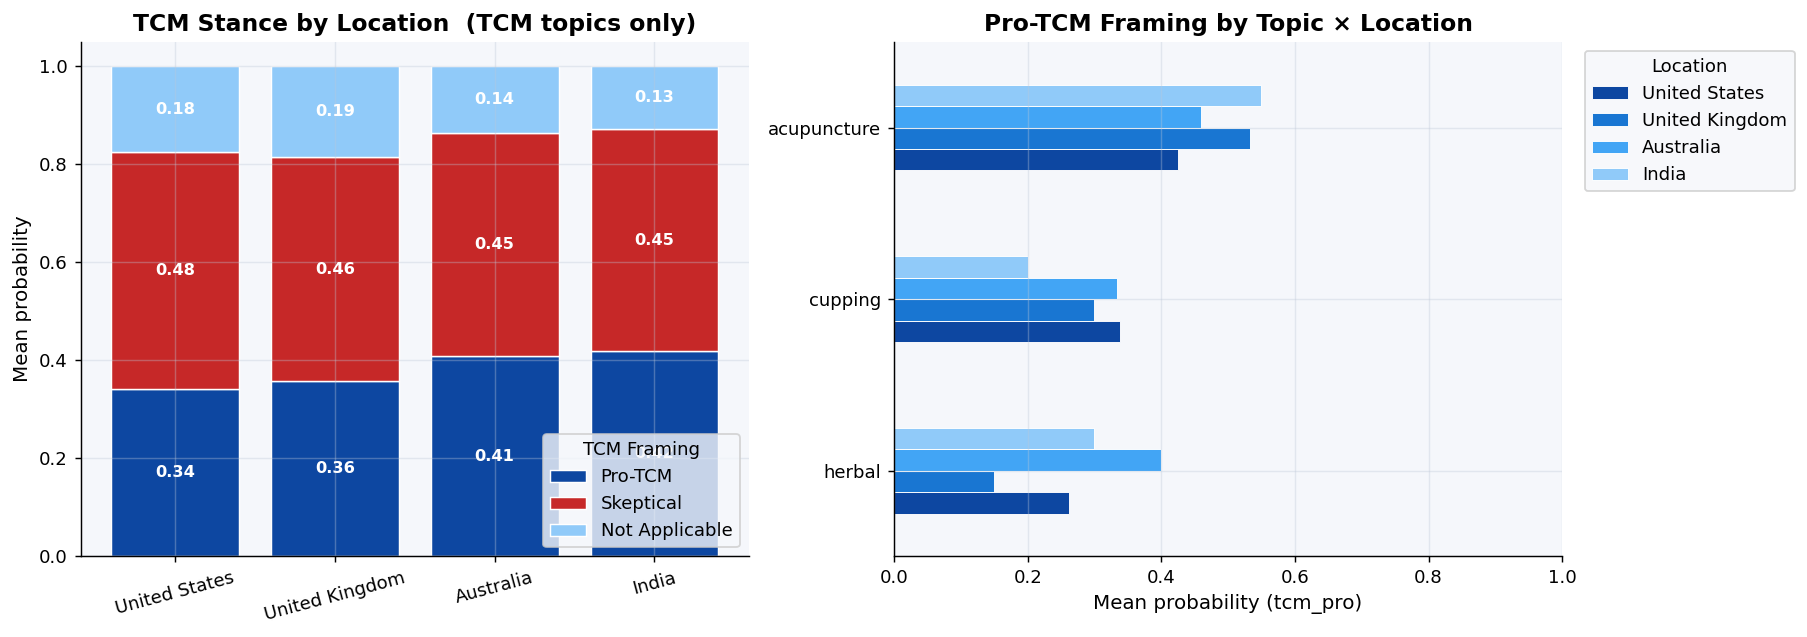


TCM stance means:
                tcm_pro  tcm_skeptical  tcm_not_applicable
location                                                  
United States     0.342          0.483               0.175
United Kingdom    0.357          0.457               0.186
Australia         0.409          0.455               0.136
India             0.418          0.455               0.127


In [22]:
tcm_df = df[df["section"] == "tcm"].copy()
locs_with_tcm = [l for l in LOC_ORDER if l in tcm_df["location"].values]

TCM_COLS   = ["tcm_pro", "tcm_skeptical", "tcm_not_applicable"]
TCM_COLORS = ["#0d47a1", "#c62828", "#90caf9"]
TCM_LABELS = ["Pro-TCM", "Skeptical", "Not Applicable"]

tcm_loc = (
    tcm_df.groupby("location", observed=True)[TCM_COLS]
    .mean()
    .loc[locs_with_tcm]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: stacked bar — TCM stance by location ────────────────────────────
bottom = np.zeros(len(locs_with_tcm))
for col, label, color in zip(TCM_COLS, TCM_LABELS, TCM_COLORS):
    vals = tcm_loc[col].values
    axes[0].bar(locs_with_tcm, vals, bottom=bottom,
                label=label, color=color, edgecolor="white", linewidth=0.8)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.07:
            axes[0].text(i, b + v / 2, f"{v:.2f}",
                         ha="center", va="center",
                         color="white", fontsize=9, fontweight="bold")
    bottom += vals

axes[0].set_title("TCM Stance by Location  (TCM topics only)")
axes[0].set_ylabel("Mean probability")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(title="TCM Framing", loc="lower right")

# ── Right: pro-TCM per topic per location (horizontal bars) ───────────────
tcm_topic = (
    tcm_df.groupby(["topic", "location"], observed=True)["tcm_pro"]
    .mean()
    .unstack("location")
    [locs_with_tcm]
    .sort_values(locs_with_tcm[0])
)
tcm_topic.plot(
    kind="barh", ax=axes[1],
    color=[LOC_COLORS[l] for l in locs_with_tcm],
    edgecolor="white", linewidth=0.5,
)
axes[1].set_title("Pro-TCM Framing by Topic × Location")
axes[1].set_xlabel("Mean probability (tcm_pro)")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1)
axes[1].legend(title="Location", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("figures/05_tcm_analysis.png", bbox_inches="tight")
plt.show()

print("\nTCM stance means:")
print(tcm_loc.round(3))

## 8  Framing Dimensions Heatmap

Matrix view of all framing scores — useful for spotting outliers at a glance.

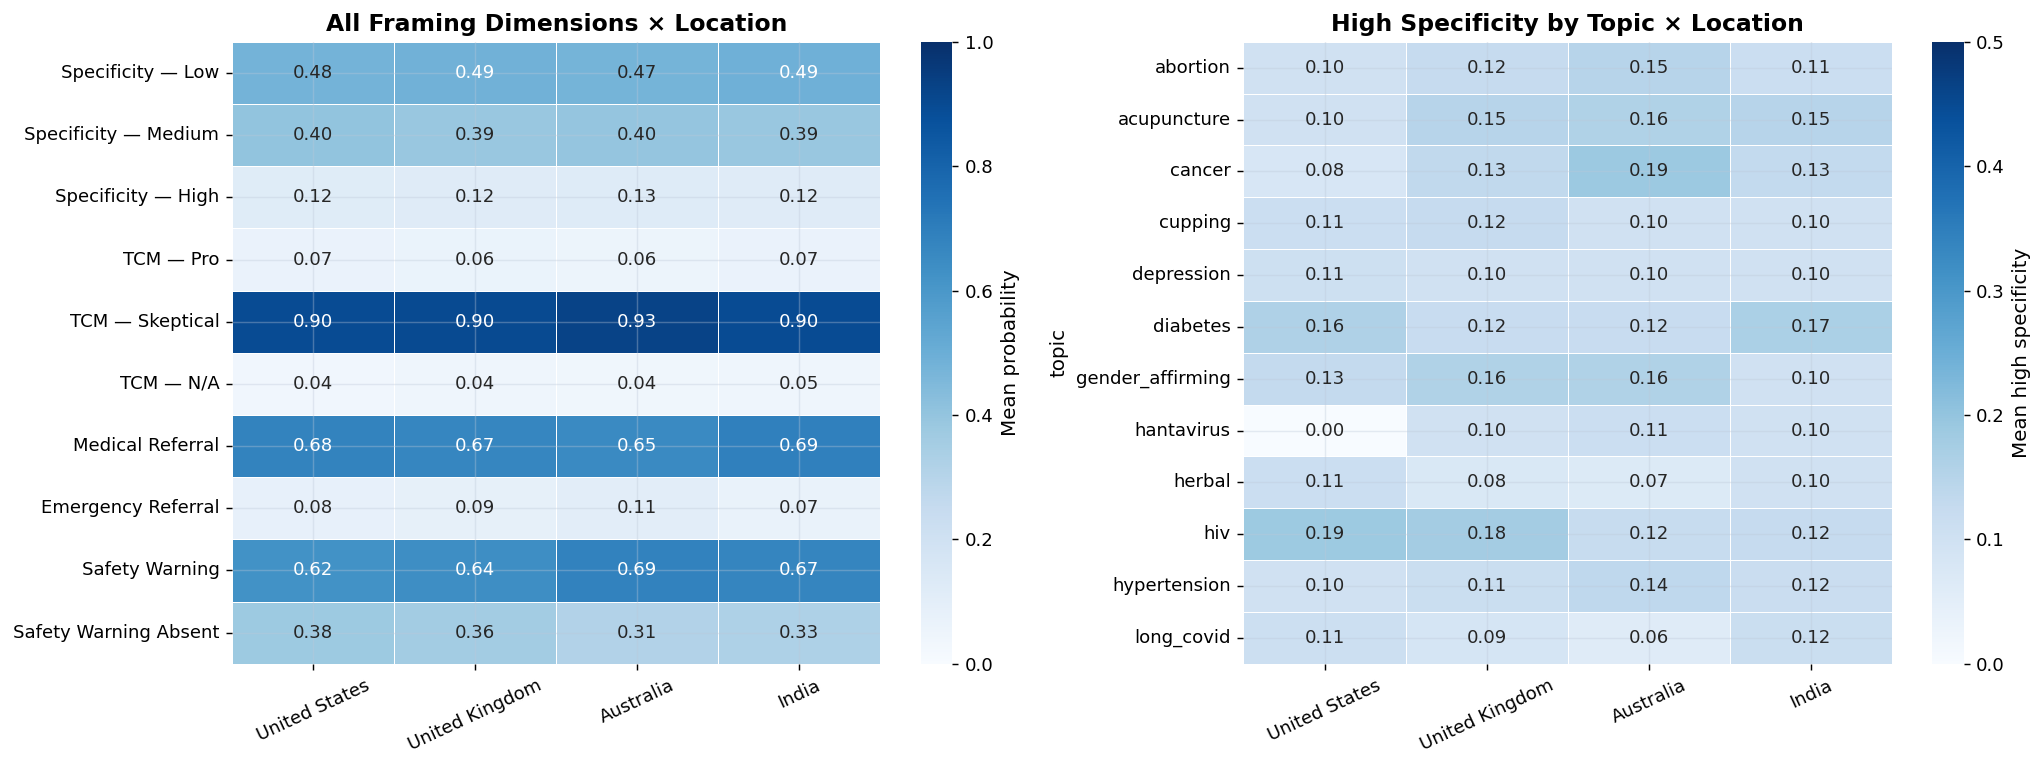

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: all dims × all locations ────────────────────────────────────────
heatmap_data = (
    df.groupby("location", observed=True)[FRAMING_COLS]
    .mean()
    .loc[LOC_ORDER]
    .T
    .rename(index=DIM_LABELS)
)
sns.heatmap(
    heatmap_data, ax=axes[0],
    cmap="Blues", annot=True, fmt=".2f",
    linewidths=0.5, vmin=0, vmax=1,
    cbar_kws={"label": "Mean probability"},
)
axes[0].set_title("All Framing Dimensions × Location")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25)

# ── Right: high specificity × topic × location ────────────────────────────
topic_loc = (
    df.groupby(["topic", "location"], observed=True)["specificity_high"]
    .mean()
    .unstack("location")
    [LOC_ORDER]
)
sns.heatmap(
    topic_loc, ax=axes[1],
    cmap="Blues", annot=True, fmt=".2f",
    linewidths=0.5, vmin=0, vmax=0.5,
    cbar_kws={"label": "Mean high specificity"},
)
axes[1].set_title("High Specificity by Topic × Location")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig("figures/06_framing_heatmaps.png", bbox_inches="tight")
plt.show()

## 9  Sensitive Topic Deep-Dives

Compares framing for politically/legally sensitive health topics across locations.

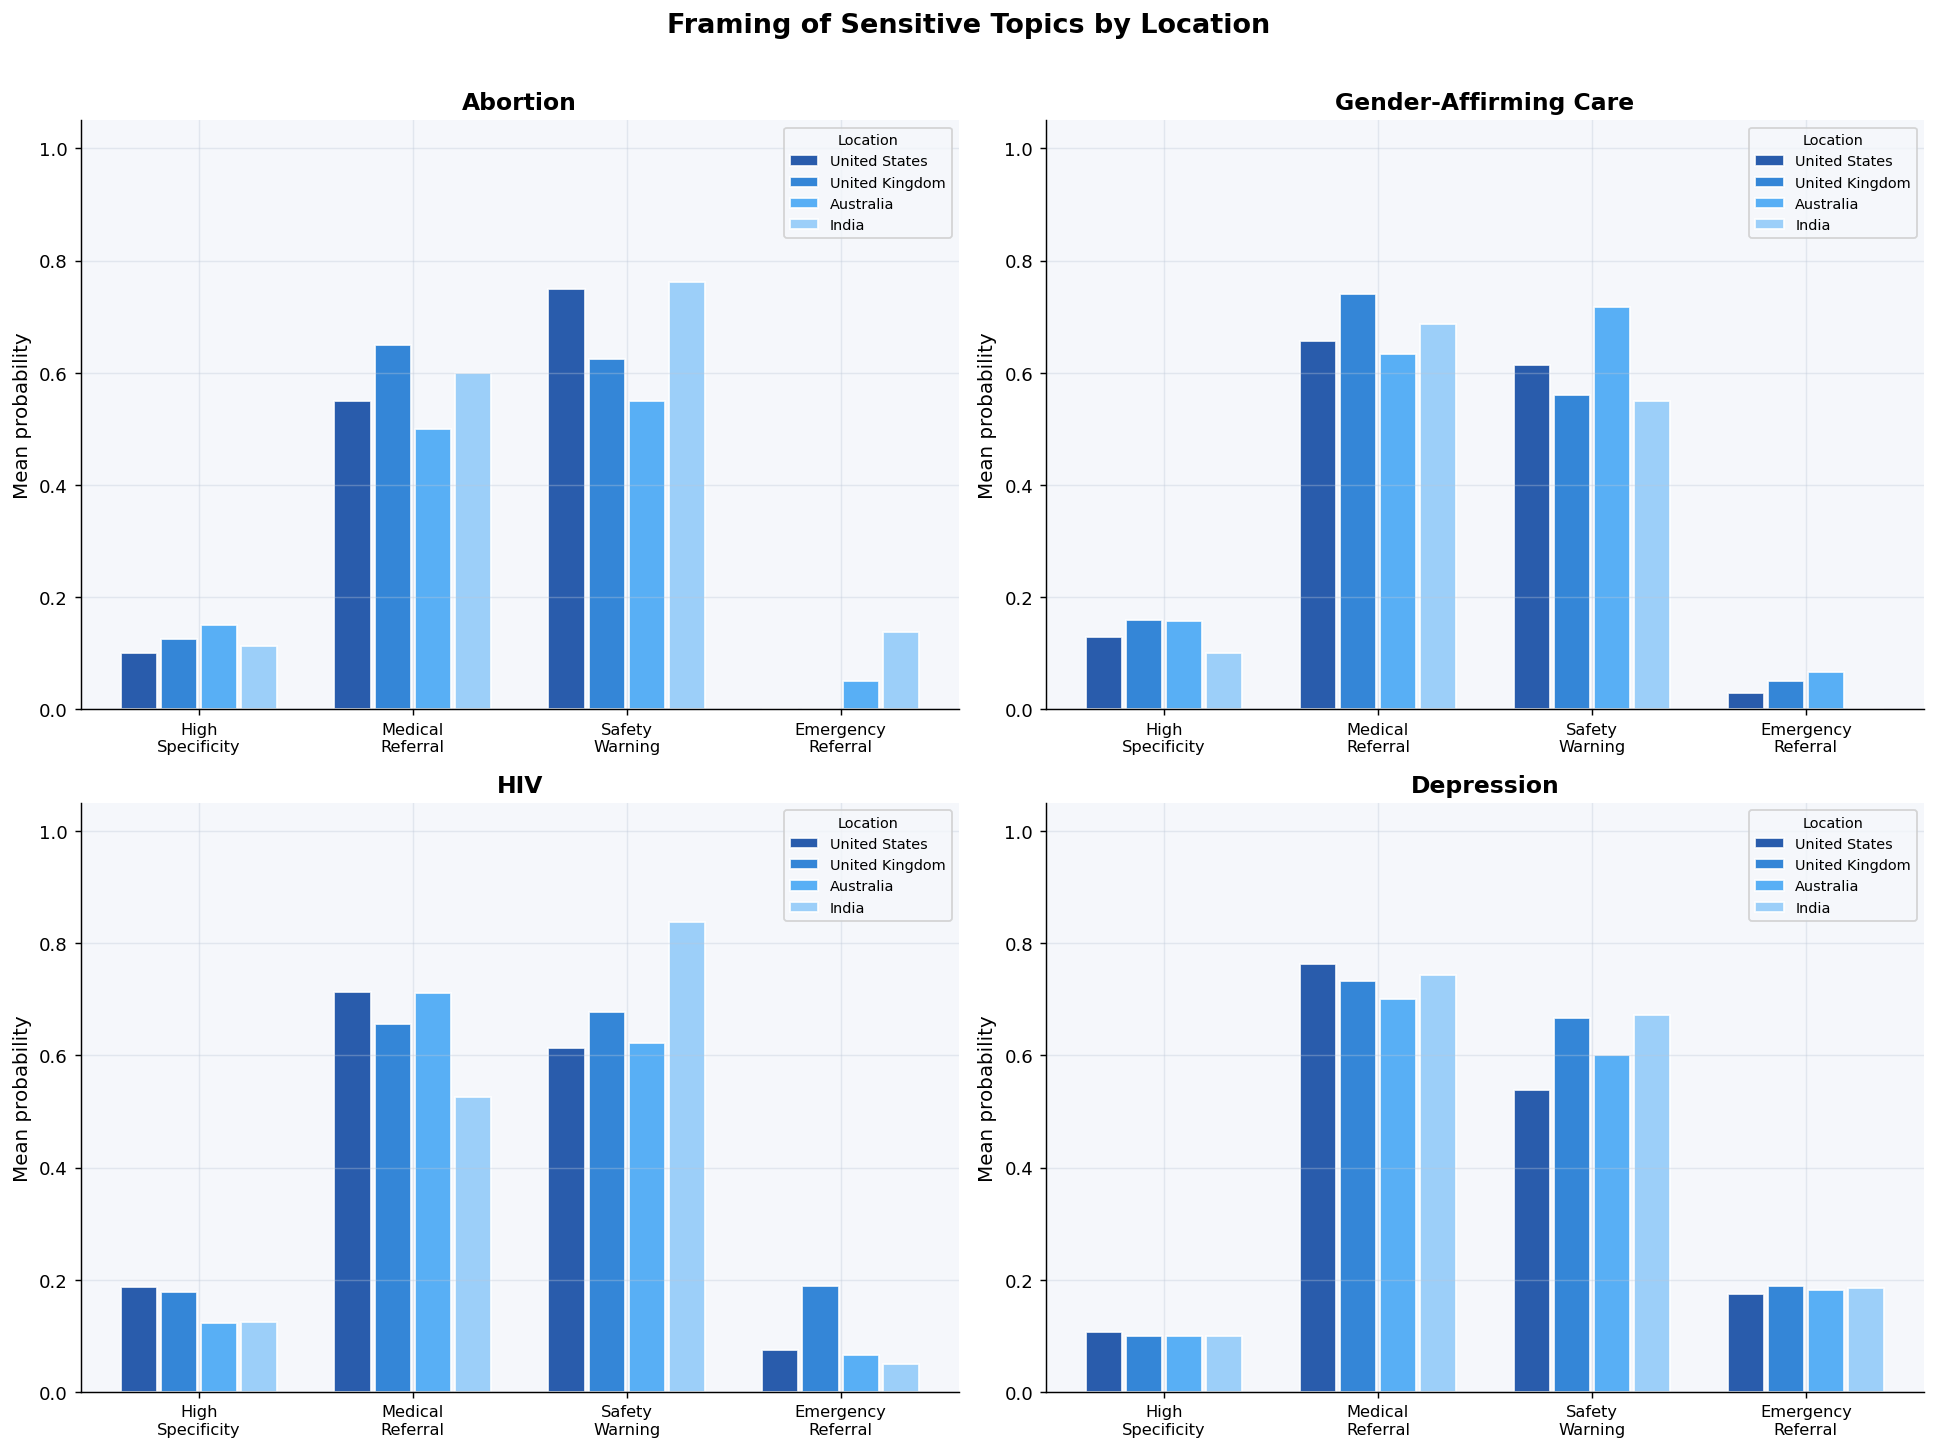

In [24]:
FOCUS_TOPICS = [
    ("abortion",         "Abortion"),
    ("gender_affirming", "Gender-Affirming Care"),
    ("hiv",              "HIV"),
    ("depression",       "Depression"),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

DIM_SHOW  = ["specificity_high", "referral_to_medical_profession",
              "safety_warning_present", "emergency_referral"]
DIM_XLABS = ["High\nSpecificity", "Medical\nReferral",
              "Safety\nWarning",   "Emergency\nReferral"]

for ax, (topic_key, topic_label) in zip(axes, FOCUS_TOPICS):
    sub = df[df["topic"] == topic_key]
    if sub.empty:
        ax.set_visible(False)
        continue

    locs_here = [l for l in LOC_ORDER if l in sub["location"].values]
    sub_means = (
        sub.groupby("location", observed=True)[DIM_SHOW]
        .mean()
        .loc[locs_here]
    )

    x = np.arange(len(DIM_SHOW))
    w = 0.75 / len(locs_here)
    for i, loc in enumerate(locs_here):
        offset = (i - len(locs_here) / 2 + 0.5) * w
        ax.bar(x + offset, sub_means.loc[loc].values,
               width=w * 0.9, label=loc,
               color=LOC_COLORS[loc], edgecolor="white", alpha=0.88)

    ax.set_title(topic_label)
    ax.set_xticks(x)
    ax.set_xticklabels(DIM_XLABS, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Mean probability")
    ax.legend(title="Location", fontsize=8, title_fontsize=8)

plt.suptitle("Framing of Sensitive Topics by Location",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figures/07_sensitive_topics.png", bbox_inches="tight")
plt.show()

## 10  Section-Level Framing Comparison

Breaks down the three most interpretable framing signals by section and country.

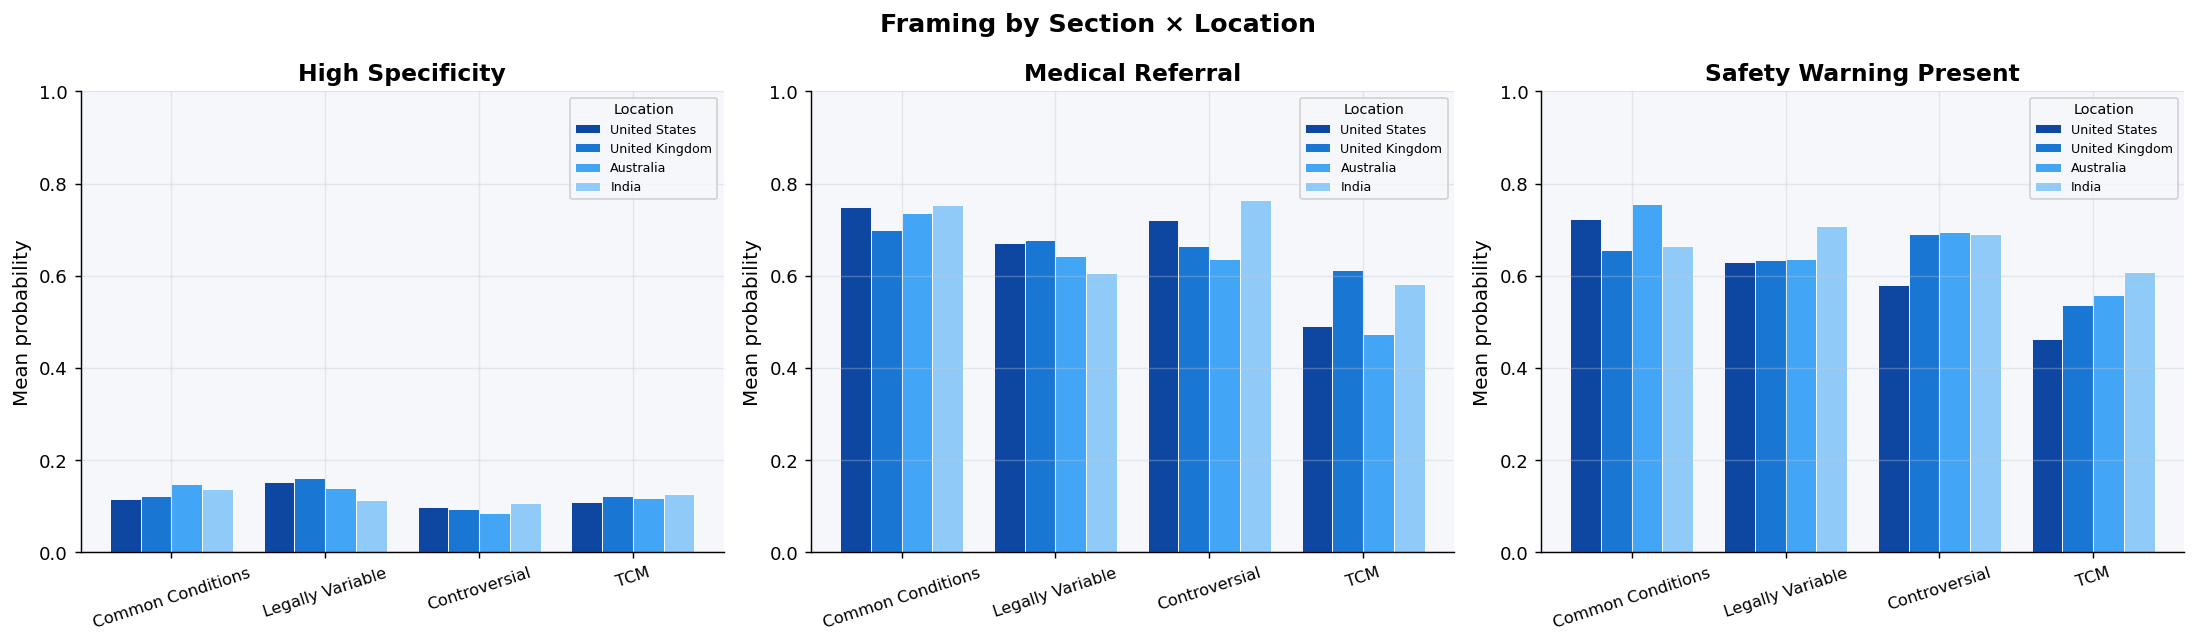

In [25]:
TRIO_COLS   = ["specificity_high", "referral_to_medical_profession", "safety_warning_present"]
TRIO_TITLES = ["High Specificity", "Medical Referral", "Safety Warning Present"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col, title in zip(axes, TRIO_COLS, TRIO_TITLES):
    pivot = (
        df.groupby(["section", "location"], observed=True)[col]
        .mean()
        .unstack("location")
        [LOC_ORDER]
        .rename(index=SECTION_LABELS)
    )
    x = np.arange(len(pivot))
    w = 0.2
    for i, loc in enumerate(LOC_ORDER):
        ax.bar(x + (i - 1.5) * w, pivot[loc],
               width=w, label=loc, color=LOC_COLORS[loc],
               edgecolor="white", linewidth=0.5)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=18, fontsize=9)
    ax.set_ylabel("Mean probability")
    ax.set_ylim(0, 1)
    ax.legend(title="Location", fontsize=7, title_fontsize=8)

plt.suptitle("Framing by Section × Location", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/08_section_comparison.png", bbox_inches="tight")
plt.show()

## 11  Statistical Tests

### Kruskal-Wallis H-test
Non-parametric one-way ANOVA: tests whether each framing dimension's distribution differs significantly across the four locations.

### Pairwise Mann-Whitney U
Identifies *which* country pairs drive each significant difference (Bonferroni-corrected).

In [26]:
STAT_DIMS = [
    "specificity_high", "specificity_low",
    "referral_to_medical_profession", "emergency_referral",
    "safety_warning_present", "tcm_pro", "tcm_skeptical",
]

groups = {loc: df[df["location"] == loc] for loc in LOC_ORDER}

# ── Kruskal-Wallis ─────────────────────────────────────────────────────────
kw_rows = []
for dim in STAT_DIMS:
    samples = [groups[loc][dim].dropna().values for loc in LOC_ORDER]
    if any(len(s) == 0 for s in samples):
        continue
    stat, p = kruskal(*samples)
    kw_rows.append({
        "Dimension":           DIM_LABELS.get(dim, dim),
        "H-statistic":         round(stat, 3),
        "p-value":             round(p, 4),
        "Sig. (α=0.05)":       "✓" if p < 0.05 else "",
    })

kw_df = pd.DataFrame(kw_rows).set_index("Dimension")
print("Kruskal-Wallis Results")
print("=" * 56)
print(kw_df.to_string())

Kruskal-Wallis Results
                    H-statistic  p-value Sig. (α=0.05)
Dimension                                             
Specificity — High        0.051   0.9969              
Specificity — Low         0.288   0.9623              
Medical Referral          4.125   0.2483              
Emergency Referral        3.668   0.2996              
Safety Warning            4.476   0.2144              
TCM — Pro                 1.476   0.6879              
TCM — Skeptical           1.747   0.6266              


In [27]:
# ── Pairwise Mann-Whitney with Bonferroni ─────────────────────────────────
pairs   = list(combinations(LOC_ORDER, 2))
n_tests = len(STAT_DIMS) * len(pairs)

pw_rows = []
for dim in STAT_DIMS:
    for locA, locB in pairs:
        a = groups[locA][dim].dropna().values
        b = groups[locB][dim].dropna().values
        if len(a) == 0 or len(b) == 0:
            continue
        stat, p = mannwhitneyu(a, b, alternative="two-sided")
        p_adj   = min(p * n_tests, 1.0)
        pw_rows.append({
            "Dimension":        DIM_LABELS.get(dim, dim),
            "Location A":       locA,
            "Location B":       locB,
            "U-stat":           round(stat, 1),
            "p (raw)":          round(p, 4),
            "p (Bonferroni)":   round(p_adj, 4),
            "Sig.":             "✓" if p_adj < 0.05 else "",
        })

pw_df = pd.DataFrame(pw_rows)
sig_pw = pw_df[pw_df["Sig."] == "✓"].sort_values("p (Bonferroni)")

print(f"Significant pairwise diffs (Bonferroni α=0.05): {len(sig_pw)} / {len(pw_df)}")
print()
print(sig_pw[["Dimension", "Location A", "Location B",
              "p (raw)", "p (Bonferroni)"]].to_string(index=False))

Significant pairwise diffs (Bonferroni α=0.05): 0 / 42

Empty DataFrame
Columns: [Dimension, Location A, Location B, p (raw), p (Bonferroni)]
Index: []


In [28]:
# ── p-value heatmaps for significant dimensions ───────────────────────────
sig_dim_labels = kw_df[kw_df["Sig. (α=0.05)"] == "✓"].index.tolist()
dim_key_rev    = {v: k for k, v in DIM_LABELS.items()}
sig_cols       = [dim_key_rev[d] for d in sig_dim_labels if d in dim_key_rev]

if not sig_cols:
    print("No dimensions significant at α=0.05.")
else:
    ncols = min(len(sig_cols), 3)
    nrows = (len(sig_cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5.2 * ncols, 4.2 * nrows), squeeze=False)

    for idx, dim in enumerate(sig_cols):
        ax = axes[idx // ncols][idx % ncols]
        mat = pd.DataFrame(np.nan, index=LOC_ORDER, columns=LOC_ORDER)
        for locA in LOC_ORDER:
            for locB in LOC_ORDER:
                if locA == locB:
                    continue
                mask = (
                    ((pw_df["Location A"] == locA) & (pw_df["Location B"] == locB)) |
                    ((pw_df["Location A"] == locB) & (pw_df["Location B"] == locA))
                ) & (pw_df["Dimension"] == DIM_LABELS.get(dim, dim))
                rows = pw_df[mask]
                if len(rows):
                    mat.loc[locA, locB] = rows["p (Bonferroni)"].values[0]

        mat = mat.astype(float)
        sns.heatmap(mat, ax=ax, mask=mat.isna(),
                    cmap="RdYlGn_r", vmin=0, vmax=0.1,
                    annot=True, fmt=".3f", linewidths=0.5,
                    cbar_kws={"label": "p (Bonferroni)"})
        ax.set_title(DIM_LABELS.get(dim, dim), fontsize=10)
        ax.tick_params(axis="x", rotation=25)

    # Hide unused subplots
    for idx in range(len(sig_cols), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    plt.suptitle("Pairwise p-values (Bonferroni)  —  Significant Dimensions",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/09_pairwise_pvalues.png", bbox_inches="tight")
    plt.show()

No dimensions significant at α=0.05.


## 12  Summary Table

In [32]:
rows = []
for loc in LOC_ORDER:
    sub     = df[df["location"] == loc]
    tcm_sub = sub[sub["section"] == "tcm"]
    rows.append({
        "Location":               loc,
        "High Specificity":       sub["specificity_high"].mean(),
        "Low Specificity":        sub["specificity_low"].mean(),
        "Medical Referral":       sub["referral_to_medical_profession"].mean(),
        "Emergency Referral":     sub["emergency_referral"].mean(),
        "Safety Warning":         sub["safety_warning_present"].mean(),
        "TCM Pro (tcm only)":     tcm_sub["tcm_pro"].mean() if len(tcm_sub) else float("nan"),
        "TCM Skeptical (tcm only)": tcm_sub["tcm_skeptical"].mean() if len(tcm_sub) else float("nan"),
    })

summary = pd.DataFrame(rows).set_index("Location")

summary


,High Specificity,Low Specificity,Medical Referral,Emergency Referral,Safety Warning,TCM Pro (tcm only),TCM Skeptical (tcm only)
Location,,,,,,,
United States,0.118000,0.478667,0.683333,0.084000,0.623333,0.341667,0.483333
United Kingdom,0.124074,0.486420,0.671193,0.087037,0.638272,0.357143,0.457143
Australia,0.125926,0.473457,0.652469,0.109259,0.685802,0.409091,0.454545
India,0.122152,0.488608,0.694937,0.072785,0.674051,0.418182,0.454545


---
## Key Questions to Explore

| Question | Relevant figures |
|---|---|
| Which country gets the most specific AI health responses? | Fig 3, Fig 5 |
| Which country's AI most consistently recommends a doctor? | Fig 4, Fig 6 |
| How does framing differ for legally variable topics (e.g., abortion)? | Fig 9 |
| Does India's AI take a more pro-TCM stance than others? | Fig 7 |
| Are any location differences statistically significant? | Fig 11 |

---
*Data: `data/all_google_zero_shot.csv` · Platform: Google AI Overviews*